In [1]:
from datetime import datetime, timedelta, timezone
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import warnings
import requests

import pandas as pd
import xarray as xr

from requests.compat import urljoin
from crlx.sikuliaq import SIKULIAQ
warnings.filterwarnings('ignore')

In [14]:
edt = datetime.now(timezone.utc)
bdt = edt - timedelta(hours = 3)

In [15]:
crlx = SIKULIAQ(verify = False)

In [18]:
apollo = crlx.get_pco2_apollo(bdt, edt)

In [23]:
ldeo


<xarray.Dataset> Size: 2MB
Dimensions:                                      (time: 14987)
Coordinates:
  * time                                         (time) datetime64[ns] 120kB ...
Data variables: (12/21)
    barometric_pressure                          (time) float64 120kB 1.005e+...
    cell_temperature                             (time) float64 120kB 39.88 ....
    co2                                          (time) float64 120kB 416.4 ....
    equilibrator_temperature                     (time) float64 120kB 1e+05 ....
    flow_rate                                    (time) float64 120kB 48.09 ....
    latitude                                     (time) float64 120kB nan ......
    ...                                           ...
    qartod_attenuated_pco2                       (time) int8 15kB 1 1 1 ... 1 1
    qartod_range_sea_water_temperature           (time) int8 15kB 1 1 1 ... 1 1
    qartod_spike_sea_water_temperature           (time) int8 15kB 9 9 1 ... 1 1
    qartod_rate_of_change_sea_water_temperature  (time) int8 15kB 9 1 1 ... 1 1
    qartod_flat_line_sea_water_temperature       (time) int8 15kB 2 2 2 ... 1 1
    qartod_attenuated_sea_water_temperature      (time) int8 15kB 1 1 1 ... 1 1

In [19]:
air_apollo = apollo.where(apollo.sample_source == 'Air')

In [25]:
ldeo.pco2.values.tolist()

[408.54,
 408.54,
 408.59,
 408.54,
 408.59,
 408.64,
 408.63,
 408.85,
 408.83,
 408.99,
 408.92,
 408.86,
 408.88,
 408.83,
 408.67,
 408.84,
 408.8,
 408.89,
 408.82,
 408.86,
 408.7,
 408.68,
 408.65,
 408.67,
 408.6,
 408.61,
 421.29,
 421.28,
 421.35,
 421.34,
 421.44,
 0.0,
 443.1,
 105.17,
 495.0,
 252.54,
 378.81,
 406.93,
 407.0,
 407.5,
 407.69,
 407.75,
 407.64,
 407.6,
 407.55,
 407.74,
 407.73,
 407.66,
 407.86,
 408.09,
 408.36,
 408.5,
 408.71,
 408.75,
 409.01,
 409.23,
 409.44,
 409.55,
 409.72,
 409.77,
 409.93,
 410.0,
 409.99,
 410.03,
 410.0,
 409.96,
 410.04,
 422.7,
 422.7,
 422.63,
 422.79,
 422.84,
 0.0,
 443.88,
 105.36,
 495.86,
 252.96,
 379.46,
 409.54,
 410.0,
 410.66,
 410.92,
 411.0,
 411.06,
 411.13,
 411.2,
 411.19,
 411.26,
 411.35,
 411.43,
 411.52,
 411.64,
 411.79,
 411.9,
 411.96,
 412.03,
 412.12,
 412.07,
 412.14,
 412.21,
 412.15,
 412.1,
 411.94,
 411.83,
 411.75,
 411.75,
 411.57,
 411.33,
 422.89,
 422.91,
 422.92,
 422.88,
 422.85,
 0.0,
 

In [17]:
ldeo = crlx.get_pco2_ldeo(bdt,edt)

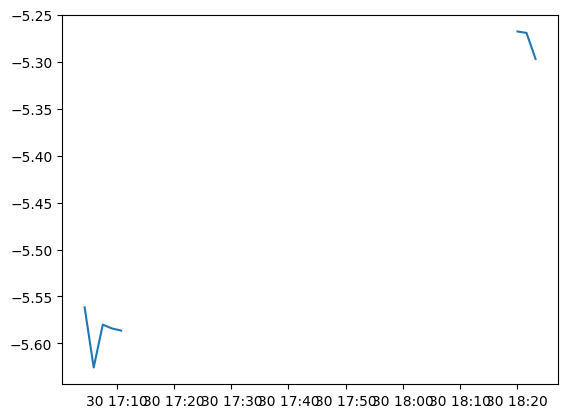

In [20]:
fig, ax = plt.subplots(1,1)
ax.plot(air_apollo.time, air_apollo.air_pco2)

In [ ]:
map

In [ ]:
df = pd.DataFrame(data)
df['time'] = pd.to_datetime(df['datetime_corrected'], format = 'mixed').dt.tz_localize(None)
df.index = df.time
ds = df.to_xarray()
ds['sensor_id'] = ds['sensor_id'].astype(str)

In [ ]:
ds

In [ ]:
crlx = SIKULIAQ(verify = False)
edt = datetime.now(timezone.utc)
bdt = edt - timedelta(hours = 3)
ds38 = crlx.get_sbe38(bdt, edt)
ds45 = crlx.get_sbe45(bdt, edt)

fig, ax = plt.subplots(1,1, figsize = (8,6), constrained_layout = True)
ax.plot(ds38.time, ds38.sea_surface_temperature, color = 'red', label = 'Centerboard SBE38')
#ax.plot(ds45.time, ds45.sea_water_temperature, color = 'blue', label = 'Main Lab SBE45 A')
ax.set_xlabel('Datetime (UTC)')
ax.set_ylabel('Temperature')
ax.legend(loc = 'upper right', ncol = 2)

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval = 30))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval = 1))

In [ ]:
[sensor_id] = np.unique(ds.sensor_id)

In [ ]:
df = crlx.get_sensor_metadata(crlx.VESSEL.SENSOR_URL, sensor_id, enabled = True)

In [ ]:
df